# New Zealand rental market, 1993–2026

**Question:** what is happening to rents in New Zealand, where, and why?

**Data:** three public CSVs from Tenancy Services (MBIE), plus Stats NZ's CPI release workbook (June 2026 quarter): monthly rental bonds by district and by region since February 1993, and quarterly bonds by dwelling type and bedrooms since 2020. A bond is lodged when a new tenancy starts, so these are rents on *new* tenancies, in nominal NZD per week.

**Method:** the CSVs are loaded and modelled in DuckDB with the SQL in `../sql`. Comparisons use 12-month trailing averages of the monthly median so seasonality doesn't distort them. This notebook runs that same model, checks the data, and works through each finding.

In [1]:
import duckdb, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

ROOT = Path.cwd().parent
con = duckdb.connect()
import os; os.chdir(ROOT)                      # the SQL reads data/raw/... relative to the project root
for f in sorted(Path("sql").glob("*.sql")):
    con.execute(f.read_text())
q = lambda sql: con.execute(sql).df()

plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .3, "font.size": 10})
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a8a"

## 1. Data profile and quality checks

In [2]:
q("""SELECT 'district (TLA) monthly' AS dataset, count(*) AS rows, min(month) AS first, max(month) AS last,
          count(DISTINCT location) AS areas FROM tla_monthly
   UNION ALL
   SELECT 'region monthly', count(*), min(month), max(month), count(DISTINCT region) FROM region_monthly
   UNION ALL
   SELECT 'dwelling × bedrooms quarterly', count(*), min(quarter), max(quarter), count(DISTINCT sa2_code) FROM dwelling_quarterly""")

,dataset,rows,first,last,areas
0,district (TLA) monthly,26448,1993-02-01,2026-07-01,67
1,region monthly,6834,1993-02-01,2026-07-01,17
2,dwelling × bedrooms quarterly,226080,2020-01-01,2026-04-01,2010


**Missing months.** Small districts have gaps, most likely where too few bonds were lodged to publish a median. They're excluded from rankings by requiring a full 12 months of data and at least 30 new bonds a month.

In [3]:
q("""SELECT location, count(*) AS months_present, 402 - count(*) AS months_missing
   FROM tla_monthly WHERE NOT is_nz_total GROUP BY 1 HAVING count(*) < 402 ORDER BY 2 LIMIT 8""")

,location,months_present,months_missing
0,Kaikoura District,277,125
1,Mackenzie District,319,83
2,Waimate District,331,71
3,Otorohanga District,345,57
4,Westland District,374,28
5,Opotiki District,376,26
6,Hurunui District,383,19
7,Wairoa District,386,16


**Reconciliation.** If the data is internally consistent, active tenancies summed across districts should match the regional totals. They agree within 0.6% in every month except one: April 2020, the COVID-19 Level 4 lockdown, when so few bonds were lodged that small districts went unpublished while still counting towards their region.

In [4]:
recon = q("""
WITH d AS (SELECT month, sum(bonds_active) AS districts FROM tla_monthly WHERE NOT is_nz_total GROUP BY 1),
     r AS (SELECT month, sum(bonds_active) AS regions FROM region_monthly WHERE NOT is_nz_total GROUP BY 1)
SELECT d.month, districts, regions, round(100.0 * (districts - regions) / regions, 3) AS diff_pct
FROM d JOIN r USING (month) ORDER BY month""")
print(recon["diff_pct"].abs().describe().round(3))
outliers = recon[recon["diff_pct"].abs() > 0.6]
assert list(outliers["month"].dt.strftime("%Y-%m")) == ["2020-04"], "unexpected months where totals diverge"
outliers

count    402.000
mean       0.072
std        0.119
min        0.000
25%        0.001
50%        0.038
75%        0.099
max        1.306
Name: diff_pct, dtype: float64


,month,districts,regions,diff_pct
326,2020-04-01,357672.0,362406.0,-1.306


## 2. The national trend: rents have stalled

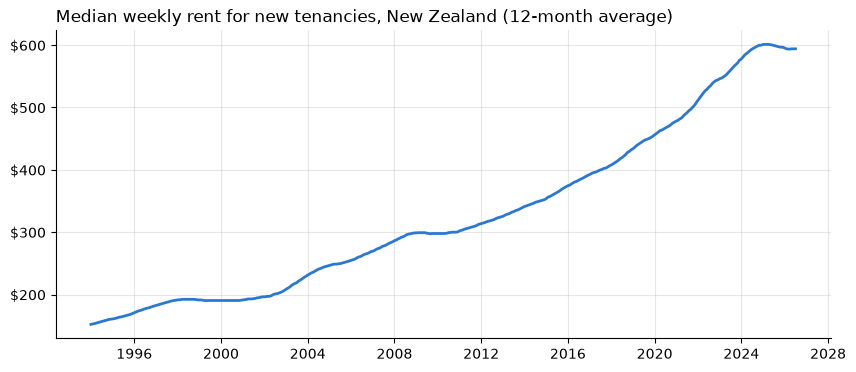

,month,median_rent,median_12m,rent_yoy_pct
317,2019-07-01,450.0,446.7,5.9
329,2020-07-01,470.0,467.1,4.4
341,2021-07-01,500.0,491.7,6.4
353,2022-07-01,540.0,532.5,8.0
365,2023-07-01,575.0,559.6,6.5
377,2024-07-01,600.0,593.8,4.3
389,2025-07-01,590.0,599.5,-1.7
401,2026-07-01,590.0,594.1,0.0


In [5]:
nz = q("SELECT * FROM nz_trend")
fig, ax = plt.subplots()
ax.plot(nz["month"], nz["median_12m"], color=BLUE, lw=2)
ax.set_title("Median weekly rent for new tenancies, New Zealand (12-month average)", loc="left")
ax.yaxis.set_major_formatter(lambda v, _: f"${v:,.0f}")
plt.show()
nz.loc[nz["month"].dt.month == 7, ["month", "median_rent", "median_12m", "rent_yoy_pct"]].tail(8)

**Is this flat spell unusual?** Searching for every run of months where the 12-month average grew less than 1% a year finds three in 33 years. The current one is the first since 2009–10 and is still running; 1998–2001 was longer.

In [6]:
nz["yoy12"] = 100 * (nz["median_12m"] / nz["median_12m"].shift(12) - 1)
flat = nz["yoy12"] < 1
runs = (flat != flat.shift()).cumsum()
spells = (nz[flat].groupby(runs[flat])
          .agg(start=("month", "min"), end=("month", "max"), months=("month", "size"))
          .sort_values("months", ascending=False))
spells

,start,end,months
yoy12,,,
2,1998-11-01,2001-03-01,29
4,2009-08-01,2010-12-01,17
6,2025-07-01,2026-07-01,13


### Adjusting for inflation

Nominal rents have been flat, but prices haven't. Deflating the quarterly median by Stats NZ's all-groups CPI (June 2018 to June 2026, the span in the release workbook) shows what a new tenancy costs in today's dollars. The CPI "actual rentals for housing" index adds a second view: rents paid by *all* tenants, not just new ones.

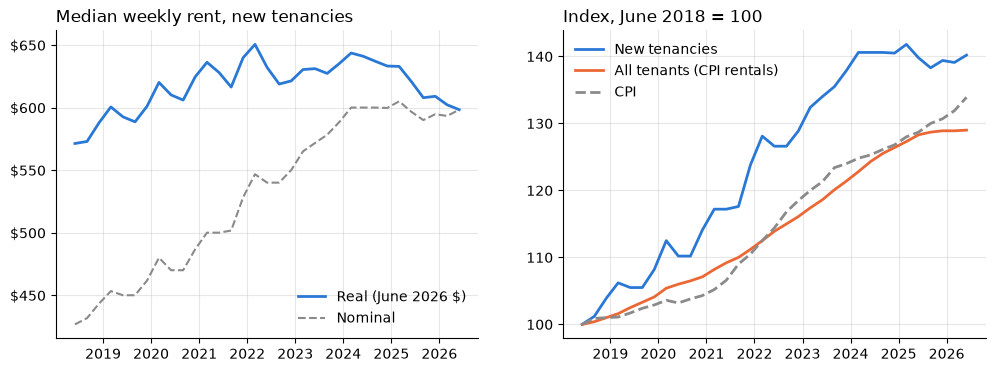

,0
latest_quarter,2026-06-01 00:00:00
real_rent_now,598.3
peak_quarter,2022-03-01 00:00:00
peak_real,650.5
real_vs_peak_pct,-8.0
nominal_2y_pct,-0.3
cpi_2y_pct,6.9
real_2y_pct,-6.7
all_tenants_2y_pct,3.8
index_new_tenancies,140.2


In [7]:
real = q("SELECT * FROM real_rent")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(real["quarter"], real["real_rent"], color=BLUE, lw=2, label="Real (June 2026 $)")
a1.plot(real["quarter"], real["nominal_rent"], color=GREY, ls="--", label="Nominal")
a1.yaxis.set_major_formatter(lambda v, _: f"${v:,.0f}"); a1.legend(frameon=False)
a1.set_title("Median weekly rent, new tenancies", loc="left")
for col, c, lab in [("index_new_tenancies", BLUE, "New tenancies"), ("index_all_tenants", ORANGE, "All tenants (CPI rentals)"), ("index_cpi", GREY, "CPI")]:
    a2.plot(real["quarter"], real[col], color=c, lw=2, ls="--" if col == "index_cpi" else "-", label=lab)
a2.legend(frameon=False); a2.set_title("Index, June 2018 = 100", loc="left")
plt.show()
q("SELECT * FROM real_rent_summary").T

**Result:** in real terms, new-tenancy rents peaked in Q1 2022 and are now 8% lower. Over the last two years they fell 6.7% after inflation (nominal −0.3%, CPI +6.9%). Rents for all tenants rose less than inflation since 2018 (+29% vs +34%) and are now slowing too.

## 3. Cities are cooling, regions are climbing

In [8]:
q("""SELECT region, median_12m_now, growth_1y_pct, growth_2y_pct, growth_5y_pct, vs_peak_pct, active_2y_pct
   FROM region_summary ORDER BY growth_2y_pct""")

,region,median_12m_now,growth_1y_pct,growth_2y_pct,growth_5y_pct,vs_peak_pct,active_2y_pct
0,Wellington,583.8,-4.9,-4.9,7.3,-5.6,10.1
1,Auckland,645.4,-0.7,-0.8,12.7,-0.9,14.8
2,Hawke's Bay,596.9,-2.3,-0.4,26.9,-2.4,9.2
3,New Zealand,594.1,-0.9,0.1,20.8,-1.2,12.3
4,Taranaki,561.7,-0.5,0.3,38.0,-0.8,9.9
5,Bay of Plenty,643.2,0.2,2.0,24.1,-0.3,9.5
6,Gisborne,615.3,-0.8,2.2,47.2,-1.5,11.7
7,Manawatu-Wanganui,518.3,1.0,2.8,29.2,0.0,11.3
8,Nelson,544.8,-1.1,3.1,20.6,-1.5,5.1
9,Northland,570.3,1.1,3.1,24.9,-0.1,14.3


## 4. Testing a hypothesis: does local supply explain local rents?

Nationally, rents stalled while active tenancies grew 6–8% a year, which suggests more supply cooled the market. If that were the mechanism, districts where tenancies grew fastest should show the slowest rent growth: a negative correlation.

n = 43 districts | Pearson r = 0.07 (p = 0.66) | Spearman rho = 0.10 (p = 0.52)


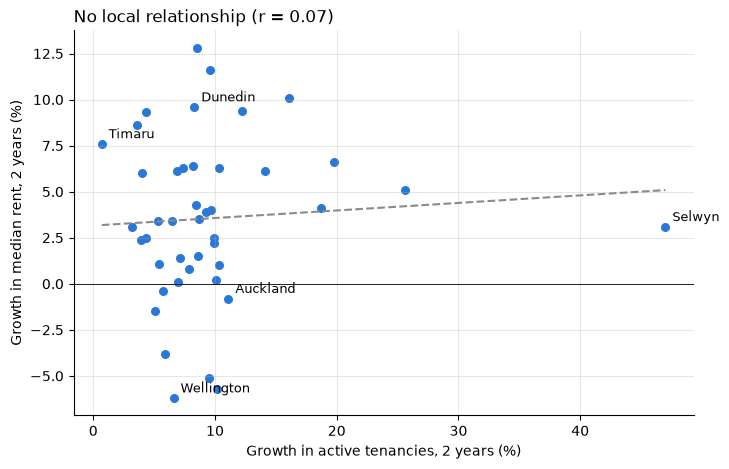

In [9]:
d = q("SELECT location, growth_2y_pct, active_2y_pct, bonds_per_month FROM tla_summary")
r, p = stats.pearsonr(d["active_2y_pct"], d["growth_2y_pct"])
rho, p_s = stats.spearmanr(d["active_2y_pct"], d["growth_2y_pct"])
fit = stats.linregress(d["active_2y_pct"], d["growth_2y_pct"])
print(f"n = {len(d)} districts | Pearson r = {r:.2f} (p = {p:.2f}) | Spearman rho = {rho:.2f} (p = {p_s:.2f})")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(d["active_2y_pct"], d["growth_2y_pct"], color=BLUE, s=30)
xs = pd.Series([d["active_2y_pct"].min(), d["active_2y_pct"].max()])
ax.plot(xs, fit.intercept + fit.slope * xs, color=GREY, ls="--")
for name in ["Wellington City", "Selwyn District", "Timaru District", "Dunedin City", "Auckland"]:
    row = d[d["location"] == name].iloc[0]
    ax.annotate(name.replace(" District", "").replace(" City", ""), (row["active_2y_pct"], row["growth_2y_pct"]),
                xytext=(5, 4), textcoords="offset points", fontsize=9)
ax.axhline(0, color="k", lw=.6)
ax.set_xlabel("Growth in active tenancies, 2 years (%)"); ax.set_ylabel("Growth in median rent, 2 years (%)")
ax.set_title(f"No local relationship (r = {r:.2f})", loc="left")
plt.show()

**Result: no relationship.** Both Pearson and rank (Spearman) correlations are near zero and far from significant. Selwyn grew tenancies by nearly half and rents still rose; Wellington City grew them modestly and rents fell. The original supply story doesn't hold at district level. The slowdown looks nationwide (interest rates, migration, the wider economy) with local demand shocks on top, such as Wellington's public-sector job cuts. Those are hypotheses for further work: this dataset alone can't test them.

## 5. Seasonality: the rental year

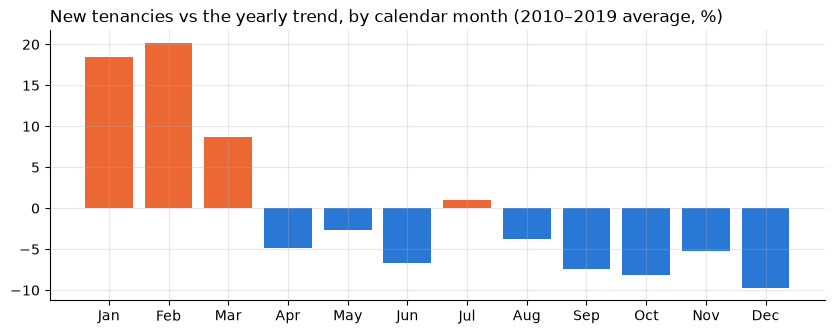

,month_num,month_name,rent_vs_trend_pct,lodgements_vs_trend_pct
0,1,Jan,2.75,18.5
1,2,Feb,1.83,20.2
2,3,Mar,-0.06,8.7
3,4,Apr,0.73,-4.9
4,5,May,-0.23,-2.7
5,6,Jun,-0.58,-6.7
6,7,Jul,-0.99,1.0
7,8,Aug,-1.10,-3.7
8,9,Sep,-0.59,-7.4
9,10,Oct,-1.13,-8.1


In [10]:
s = q("SELECT * FROM seasonality")
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(s["month_name"], s["lodgements_vs_trend_pct"], color=[ORANGE if v > 0 else BLUE for v in s["lodgements_vs_trend_pct"]])
ax.set_title("New tenancies vs the yearly trend, by calendar month (2010–2019 average, %)", loc="left")
plt.show()
s

## 6. A data-quality issue in the bedroom breakdown

From late 2024 the bedroom field changes behaviour: first the share of bonds with no bedroom count jumps, then those unknowns appear to be recorded as "1 bedroom". The result is that 1-bedroom houses suddenly show the same median rent as 3-bedroom houses, which isn't plausible.

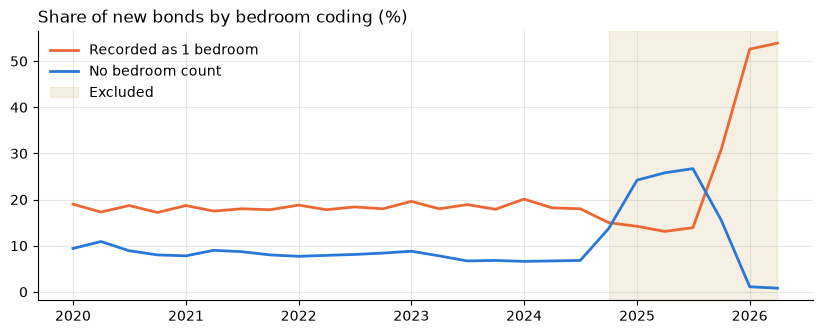

bedrooms,1,3
quarter,,
2024-01-01,410.0,650.0
2024-04-01,430.0,650.0
2024-07-01,430.0,650.0
2024-10-01,450.0,650.0
2025-01-01,500.0,650.0
2025-04-01,500.0,650.0
2025-07-01,500.0,640.0
2025-10-01,575.0,645.0
2026-01-01,580.0,650.0


In [11]:
bc = q("SELECT * FROM bedroom_coding_check")
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(bc["quarter"], bc["pct_one_bed"], color=ORANGE, lw=2, label="Recorded as 1 bedroom")
ax.plot(bc["quarter"], bc["pct_unknown_beds"], color=BLUE, lw=2, label="No bedroom count")
ax.axvspan(pd.Timestamp("2024-10-01"), bc["quarter"].max(), color="#c9a04c", alpha=.15, label="Excluded")
ax.set_title("Share of new bonds by bedroom coding (%)", loc="left"); ax.legend(frameon=False)
plt.show()
q("""SELECT quarter, bedrooms, median_rent FROM dwelling_quarterly
   WHERE is_nz_total AND dwelling_type = 'House' AND bedrooms IN ('1','3') AND quarter >= '2024-01-01'
   ORDER BY quarter, bedrooms""").pivot(index="quarter", columns="bedrooms", values="median_rent")

**Decision:** bedroom comparisons use 2020 Q1 to 2024 Q3 only. Totals across all bedrooms are unaffected and used for every period.

## 7. Conclusions and limitations

1. **Rents have stalled, and are falling in real terms.** The national median has held at about $590–600 a week since 2024, the first flat spell since 2009–10. After inflation, new-tenancy rents are 8% below their 2022 peak.
2. **The slowdown is uneven.** Wellington-area cities are down 4–6% in two years and Auckland is flat, while the West Coast, Southland and Otago are still rising 8–11%.
3. **Local supply doesn't explain it.** There's no district-level link between tenancy growth and rent growth (r ≈ 0.07).
4. **Rentals follow a strong seasonal cycle.** New tenancies run about 20% above trend in February, and rents peak in January.
5. **The cheap end is being squeezed.** The upper-to-lower quartile ratio has fallen from 1.73 (2015) to 1.44.

**Limitations.** Most comparisons use nominal rents; the inflation-adjusted view covers June 2018 onwards, the span of the CPI release workbook. Bonds capture new tenancies only, not rents paid by sitting tenants. Medians for small districts are noisy, so rankings require 30+ new bonds a month. Correlation across districts can't establish causes.